# Bab 3: Statistical Experiments and Significance Testing

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Ringkasan Bab
Eksperimen, terutama A/B test, adalah cara standar untuk menjawab pertanyaan "apakah perlakuan ini berpengaruh?". Bab ini menunjukkan cara merancang eksperimen dan memutuskan apakah perbedaan yang teramati itu nyata atau hanya kebetulan.

1. **A/B testing.** Perlakuan dibandingkan dengan kontrol, dengan penugasan acak.
2. **Uji hipotesis.** Hipotesis nol dan alternatif, uji satu arah dan dua arah.
3. **Resampling.** Permutation test.
4. **Signifikansi statistik dan p-value.** Alpha, error tipe 1 dan tipe 2, serta hal-hal yang perlu diwaspadai.
5. **Uji t**, **multiple testing**, dan **derajat bebas**.
6. **ANOVA.** Membandingkan lebih dari dua kelompok dengan statistik F.
7. **Uji chi-square** dan **uji eksak Fisher**.
8. **Algoritma multi-arm bandit.**
9. **Power dan ukuran sampel.**

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power
import seaborn as sns
import matplotlib.pylab as plt

DATA = Path('..') / 'data'
sns.set_style('whitegrid')
random.seed(1); np.random.seed(1)

## 1. A/B Testing
**Penjelasan teori.** **A/B test** membandingkan dua kelompok yang hanya berbeda pada satu perlakuan (misalnya halaman web A dan B), dengan **penugasan acak** untuk subjeknya. Pengacakan membuat kedua kelompok sebanding, sehingga selisih pada **metrik respons** bisa dikaitkan dengan perlakuannya. Praktik yang baik: tentukan satu metrik sebelum eksperimen, tentukan ukuran sampel di awal, dan jangan berhenti seenaknya setelah mengintip hasil. **Kelompok kontrol** wajib ada, karena membandingkan dengan data historis rawan terganggu faktor lain (confounder).

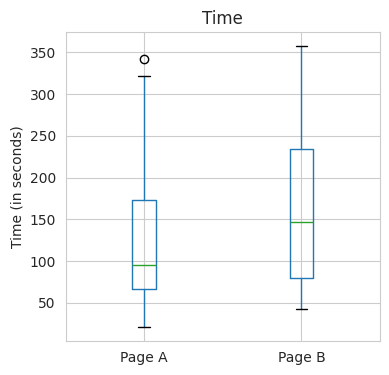

In [2]:
session_times = pd.read_csv(DATA / 'web_page_data.csv')
session_times.Time = 100 * session_times.Time  # convert to seconds scale used in the book
ax = session_times.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel(''); ax.set_ylabel('Time (in seconds)')
plt.suptitle(''); plt.tight_layout(); plt.show()

In [3]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print('Observed difference (B - A):', mean_b - mean_a)

Observed difference (B - A): 35.66666666666667


## 2. Uji Hipotesis
**Penjelasan teori.** Uji hipotesis dipakai supaya kita tidak tertipu oleh kebetulan.
- **Hipotesis nol $H_0$:** tidak ada efek nyata, perbedaan hanya karena kebetulan.
- **Hipotesis alternatif $H_1$:** efeknya nyata.
- **Uji satu arah** hanya menghitung kejadian ekstrem di satu sisi, sedangkan **uji dua arah** menghitung kedua sisi. Arah uji dipilih sebelum melihat data, dan uji dua arah adalah pilihan yang lebih konservatif.

## 3. Resampling
**Penjelasan teori.** Resampling berarti mengambil sampel berulang dari data yang ada untuk menilai variabilitas acak.
- **Permutation test.** Gabungkan kedua kelompok, acak labelnya *tanpa pengembalian*, bagi lagi menjadi kelompok dengan ukuran semula, hitung statistiknya, lalu ulangi. Kumpulan statistik tersebut menggambarkan apa yang akan terjadi kalau $H_0$ benar. **P-value** adalah proporsi hasil permutasi yang sama atau lebih ekstrem dibanding hasil yang diamati.
- **Permutasi eksak:** semua kemungkinan pembagian didaftar satu per satu (hanya layak untuk sampel kecil).
- **Bootstrap permutation:** pengambilan dilakukan *dengan* pengembalian.
- Metodenya tidak butuh asumsi distribusi, jadi cukup serbaguna.

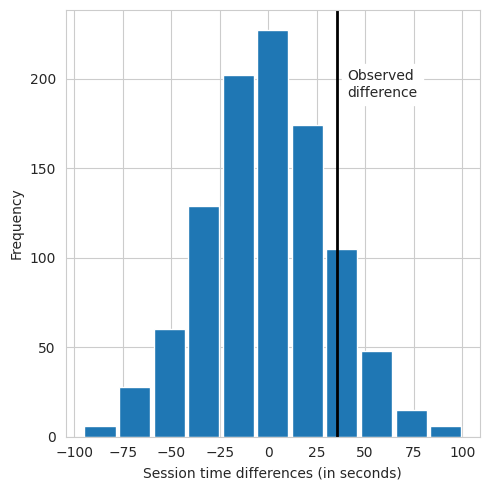

In [4]:
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]

def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_b - mean_a, color='black', lw=2)
ax.text(mean_b - mean_a + 5, 190, 'Observed\ndifference', bbox={'facecolor': 'white'})
ax.set_xlabel('Session time differences (in seconds)'); ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()

In [5]:
print('Permutation p-value:', np.mean(np.array(perm_diffs) > mean_b - mean_a))

Permutation p-value: 0.121


## 4. Signifikansi Statistik dan P-Value
**Penjelasan teori.**
- **P-value** adalah peluang mendapatkan hasil yang sama ekstremnya dengan yang diamati *kalau $H_0$ benar*. P-value **bukan** peluang bahwa $H_0$ benar.
- **Alpha ($\alpha$)** adalah ambang batas yang ditetapkan di awal (biasanya 0,05). Kalau $p<\alpha$, hasilnya disebut **signifikan secara statistik**.
- **Error tipe 1** (false positive) berarti menyatakan ada efek padahal tidak ada (peluangnya sama dengan $\alpha$). **Error tipe 2** (false negative) berarti gagal mendeteksi efek yang sebenarnya ada (peluangnya $\beta$, dan power $=1-\beta$).
- **Hal yang perlu diwaspadai (pernyataan ASA):** p-value tidak mengukur besar efek atau pentingnya efek, sensitif terhadap ukuran sampel, dan angka 0,05 bukan batas ajaib. Dalam data science, p-value lebih tepat dipakai sebagai filter untuk menilai apakah suatu hasil mungkin hanya noise, bukan sebagai keputusan akhir.

Observed difference: 0.0368%


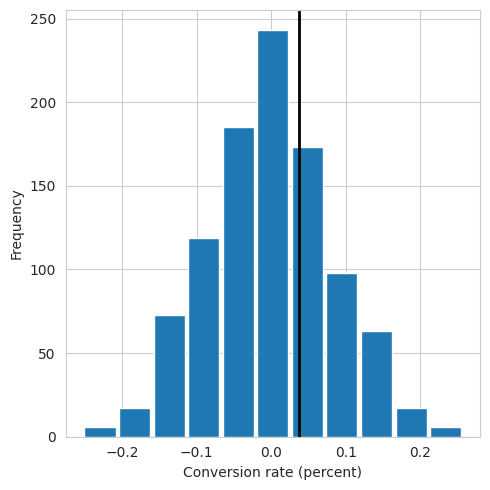

In [6]:
# Binomial/proportion example via resampling (conversion rates)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')
conversion = [0] * 45945 + [1] * 382
conversion = pd.Series(conversion)

def perm_fun2(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

perm_diffs = [100 * perm_fun2(conversion, 23739, 22588) for _ in range(1000)]
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.set_xlabel('Conversion rate (percent)'); ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()

In [7]:
# p-value from permutation and from the normal approximation (prop z-test)
print('Permutation p-value:', np.mean([diff > obs_pct_diff for diff in perm_diffs]))
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value for single sided test: {p_value / 2:.4f}')

Permutation p-value: 0.317
p-value for single sided test: 0.3498


## 5. Uji t
**Penjelasan teori.** **Statistik uji** merangkum perbedaan yang ada. **Statistik t** menstandarkan selisih mean dengan standard error-nya:
$$t=\frac{\bar{x}_B-\bar{x}_A}{\sqrt{s_A^2/n_A+s_B^2/n_B}}$$
Nilai ini dibandingkan dengan distribusi t sehingga p-value bisa dihitung secara analitik. Hasilnya merupakan pendekatan dari yang dikerjakan permutation test secara brute force. Versi Welch tidak mengasumsikan varians kedua kelompok sama.

In [8]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time,
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'tstat: {tstat:.4f}, p-value: {pvalue:.4f}, df: {df:.1f}')

p-value for single sided test: 0.1408
tstat: -1.0983, p-value: 0.1408, df: 27.7


## 6. Multiple Testing
**Penjelasan teori.** Kalau kita menjalankan banyak uji, sebagian akan tampak "signifikan" hanya karena kebetulan. Pada $\alpha=0{,}05$ dengan 20 uji yang independen, $P(\text{minimal satu false positive})=1-0{,}95^{20}\approx64\%$. Solusinya adalah **menyesuaikan p-value** (Bonferroni memakai $\alpha/m$, lalu ada Holm, dan Benjamini-Hochberg untuk mengendalikan **false discovery rate**) dan menyisihkan data untuk mengonfirmasi temuan. Ini adalah versi formal dari *vast search effect* yang dibahas di Bab 2.

In [9]:
print('P(at least 1 false positive in 20 tests):', 1 - 0.95**20)
pvals = np.array([0.001, 0.008, 0.02, 0.04, 0.2, 0.5])
for method in ('bonferroni', 'holm', 'fdr_bh'):
    reject, p_adj, _, _ = sm.stats.multipletests(pvals, alpha=0.05, method=method)
    print(f'{method:11s}', np.round(p_adj, 3), reject)

P(at least 1 false positive in 20 tests): 0.6415140775914581
bonferroni  [0.006 0.048 0.12  0.24  1.    1.   ] [ True  True False False False False]
holm        [0.006 0.04  0.08  0.12  0.4   0.5  ] [ True  True False False False False]
fdr_bh      [0.006 0.024 0.04  0.06  0.24  0.5  ] [ True  True  True False False False]


## 7. Derajat Bebas
**Penjelasan teori.** Derajat bebas adalah banyaknya nilai yang masih bebas bervariasi setelah sebagian parameter diestimasi. Membagi dengan $n-1$ pada varians sampel mengompensasi satu derajat bebas yang terpakai untuk mengestimasi mean. Konsep ini muncul di distribusi t, chi-square, dan F, juga di regresi (misalnya untuk variabel faktor, satu dummy harus dibuang supaya tidak terjadi **multikolinearitas**).

## 8. ANOVA
**Penjelasan teori.** **Analisis varians (ANOVA)** menguji apakah *beberapa* kelompok punya mean yang sama, sehingga kita tidak perlu banyak uji berpasangan yang memicu masalah multiple testing.
- Di bawah $H_0$, semua perbedaan antar kelompok hanya acak. Data diacak ke seluruh kelompok, lalu dihitung **varians antar mean kelompok**.
- **Statistik F** $=\dfrac{\text{varians antar kelompok (MSB)}}{\text{varians dalam kelompok (MSW)}}$. Nilai F yang besar berarti perbedaan mean antar kelompok lebih besar daripada yang bisa dijelaskan kebetulan.
- **ANOVA dua arah** menganalisis dua faktor (beserta interaksinya) sekaligus.

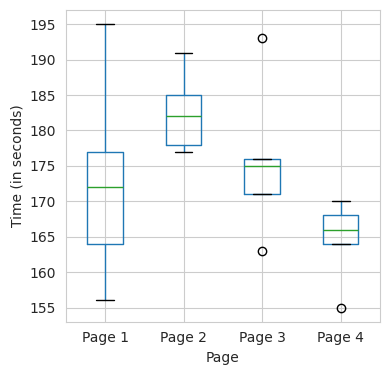

In [10]:
four_sessions = pd.read_csv(DATA / 'four_sessions.csv')
ax = four_sessions.boxplot(by='Page', column='Time', figsize=(4, 4))
ax.set_xlabel('Page'); ax.set_ylabel('Time (in seconds)')
plt.suptitle(''); plt.title(''); plt.tight_layout(); plt.show()

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655


Pr(Prob) 0.08433333333333333


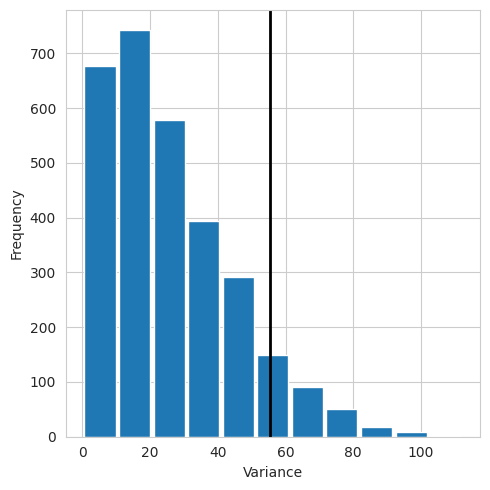

In [11]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)

def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]

perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color='black', lw=2)
ax.set_xlabel('Variance'); ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()

In [12]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
print(aov_table)
# SciPy one-way ANOVA
res = stats.f_oneway(*[g.Time.values for _, g in four_sessions.groupby('Page')])
print(f'F-Statistic: {res.statistic:.4f}, p-value: {res.pvalue:.4f}')

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN
F-Statistic: 2.7398, p-value: 0.0776


## 9. Uji Chi-Square
**Penjelasan teori.** Uji ini memeriksa apakah **frekuensi** yang diamati pada tiap kategori sesuai dengan yang **diharapkan** di bawah $H_0$ (misalnya headline dan klik saling independen).
$$\chi^2=\sum\frac{(\text{observed}-\text{expected})^2}{\text{expected}}$$
Distribusi acuannya adalah chi-square dengan $df=(r-1)(c-1)$. Versi resampling-nya mengambil sampel dari "kotak" berisi angka 1 (klik) dan 0 (tidak klik), lalu menghitung $\chi^2$ berulang kali. Aturan praktisnya, frekuensi harapan minimal 5 per sel. Kalau tidak terpenuhi, pakai **uji eksak Fisher**.

In [13]:
click_rate = pd.read_csv(DATA / 'click_rates.csv')
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [14]:
# Resampling approach
row_average = clicks.mean(axis=1)
pd.DataFrame({'Headline A': row_average, 'Headline B': row_average, 'Headline C': row_average})

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect for observe in row])
    return np.sum(pearson_residuals)

expected = [34 / 3, 1000 - 34 / 3]   # expected clicks / no-clicks per headline (34 clicks overall, 1000 views each)
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

box = [1] * 34
box.extend([0] * 2966)
random.seed(1)
perm_chi2 = [perm_fun(box) for _ in range(2000)]
resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4765


In [15]:
# Statistical (asymptotic) approach
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


### Uji Eksak Fisher
**Penjelasan teori.** Untuk jumlah yang kecil, semua tabel yang mungkin dengan total baris dan kolom yang sama didaftar (distribusi hipergeometrik), lalu dihitung peluang eksak dari tabel yang sama atau lebih ekstrem. Fungsi `scipy.stats.fisher_exact` menangani tabel 2×2.

In [16]:
print(stats.fisher_exact(clicks.iloc[:, :2].values))

SignificanceResult(statistic=np.float64(1.7606490872210954), pvalue=np.float64(0.2835969483988402))


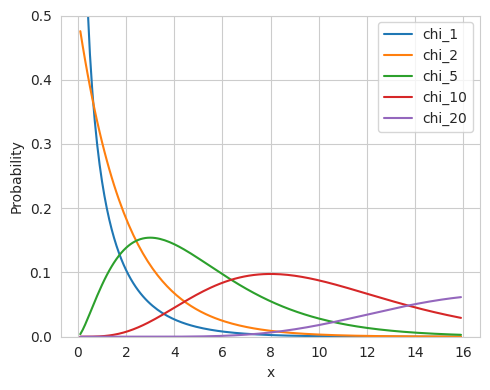

In [17]:
# Figure: chi-square distribution for several degrees of freedom
x = [i / 10 for i in range(1, 160)]
chi = pd.DataFrame({'x': x,
                    'chi_1': stats.chi2.pdf(x, df=1),
                    'chi_2': stats.chi2.pdf(x, df=2),
                    'chi_5': stats.chi2.pdf(x, df=5),
                    'chi_10': stats.chi2.pdf(x, df=10),
                    'chi_20': stats.chi2.pdf(x, df=20)})
fig, ax = plt.subplots(figsize=(5, 4))
chi.plot(x='x', ax=ax)
ax.set_ylim(0, 0.5); ax.set_xlabel('x'); ax.set_ylabel('Probability')
plt.tight_layout(); plt.show()

## 10. Algoritma Multi-Arm Bandit
**Penjelasan teori.** A/B test tradisional memakai pembagian traffic yang tetap dan durasi yang tetap. **Multi-armed bandit** (istilahnya dari mesin slot) menggeser traffic secara adaptif ke opsi yang lebih baik *selama* eksperimen berjalan, sambil menyeimbangkan **eksplorasi** (belajar) dan **eksploitasi** (mengambil keuntungan).
- **ε-greedy:** dengan peluang ε pilih opsi secara acak, sisanya pilih opsi yang sejauh ini terbaik.
- **Thompson sampling:** ambil sampel laju sukses tiap opsi dari posterior Beta, lalu pilih yang nilainya paling tinggi. Ini pendekatan Bayesian yang menyeimbangkan dirinya sendiri.

Cocok dipakai ketika ada banyak perlakuan, keputusan harus cepat, atau menampilkan opsi yang lebih buruk itu mahal (headline, iklan, rekomendasi).

In [18]:
# Simple Thompson-sampling simulation with three arms
rng = np.random.default_rng(1)
true_rates = np.array([0.020, 0.025, 0.040])
successes = np.ones(3); failures = np.ones(3)   # Beta(1,1) priors
pulls = np.zeros(3, dtype=int)
for _ in range(20000):
    arm = np.argmax(rng.beta(successes, failures))
    reward = rng.random() < true_rates[arm]
    successes[arm] += reward; failures[arm] += 1 - reward; pulls[arm] += 1
print('Pulls per arm:', pulls)
print('Estimated rates:', np.round(successes / (successes + failures), 4))

Pulls per arm: [  278  1469 18253]
Estimated rates: [0.0143 0.0313 0.0434]


## 11. Power dan Ukuran Sampel
**Penjelasan teori.** **Power** adalah peluang mendeteksi efek nyata dengan ukuran tertentu ($1-\beta$). Power terkait dengan empat besaran: **besar efek**, **ukuran sampel**, **taraf signifikansi $\alpha$**, dan **power** itu sendiri. Kalau tiga di antaranya ditetapkan, yang keempat bisa dihitung. Target yang umum adalah power 0,8. Efek yang kecil butuh sampel yang besar, dan perhitungannya sebaiknya dilakukan *sebelum* eksperimen agar tidak terjebak uji yang kekurangan power. Besar efek di sini memakai Cohen's $d=\frac{\mu_1-\mu_0}{\sigma}$ (atau Cohen's $h$ untuk proporsi).

In [19]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.NormalIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116601.715
Sample Size: 5487.731


## Poin Penting
- Eksperimen acak dengan kelompok kontrol adalah standar emas untuk klaim sebab-akibat.
- Permutation test memberi p-value dengan asumsi minimal. Uji t, ANOVA, dan chi-square adalah padanan berbasis rumusnya.
- Kendalikan false positive ketika menguji banyak hipotesis, dan rencanakan power serta ukuran sampel di awal.
- P-value adalah alat untuk menilai apakah suatu hasil mungkin hanya kebetulan, bukan ukuran seberapa penting hasil tersebut.